## In this tutorial we will use convolutional neural network(CNN) to classify Ising model that you have done with logistic regression and SVM in your homework 1

We use the same dataset maintained by Pankajm and loaded the same way as before.

This code is from ChatGPT and modified by Gang Xu for the PSI scientific machine learning couse.

### Import libraries <span style="color:blue">( no need to change)

In [13]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
import pickle

from tqdm.notebook import tqdm

import torch as tc
device = tc.accelerator.current_accelerator().type if tc.accelerator.is_available() else "cpu"
print(f"Using {device} device")

import time
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, random_split, DataLoader

Using cuda device


### Loading data <span style="color:blue">( no need to change)

In [14]:
#This is gratefully borrowed with permission from the notebooks maintained by P. Mehta.

######### LOAD DATA
######### The data consists of 16*10000 samples taken in T=np.arange(0.25,4.0001,0.25):
data_file_name = 'Ising2DFM_reSample_L40_T=All.pkl'
######### The labels are obtained from the following file:
label_file_name = 'Ising2DFM_reSample_L40_T=All_labels.pkl'


############ DATA
with open(data_file_name, 'rb') as pickle_file:
#r=read b=binary pickle must be read in binary mode and needs to be open
# with... as... will automatically close the file after opening it is safer
    data = pickle.load(pickle_file) # pickle reads the file and returns the Python object (1D array, compressed bits) and store in data

#### Decompress array and reshape for convenience
data = np.unpackbits(data).reshape(-1, 1600)
#data has byte (8bits) unpackbits unpack it into 8 bits return a bunch of 0 and 1s
#-1: figure out how many rows there are, each row has 1600=40*40 bits The length of the lattice is 40
data=data.astype('int')
#now convert the datatype to integer

#### map 0 state to -1 (Ising variable can take values +/-1)
data[np.where(data==0)]=-1
# np.where(data==0) find all indices where data is 0

###### READ LABELS (convention is 1 for ordered states and 0 for disordered states)
with open(label_file_name, 'rb') as pickle_file:
    labels = pickle.load(pickle_file) # pickle reads the file and returns the Python object (here just a 1D array with the binary labels)
print(data.shape) # the shape of the features
print(np.unique(labels)) # the unique labels
print(labels[0]) ## the ordered phase is classified as 1 disorder is classified as 0


C:\Users\danie\AppData\Local\Temp\ipykernel_22340\419892156.py:14: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(pickle_file) # pickle reads the file and returns the Python object (1D array, compressed bits) and store in data


(160000, 1600)
[0 1]
1


C:\Users\danie\AppData\Local\Temp\ipykernel_22340\419892156.py:29: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  labels = pickle.load(pickle_file) # pickle reads the file and returns the Python object (here just a 1D array with the binary labels)


### Make sure our data are of right shape and type

In [32]:
X = tc.tensor(data, dtype=tc.float32) ### float64 will use even more memory
y = tc.tensor(labels, dtype=tc.long) #### pytorch requires int64 to index into the logits tensor


# reshape to images: (N, 1, 40, 40)
X = X.view(-1, 1, 40, 40)  #(N, C, H, W) batch channel height weighth N is number of images C: grayscale channel is 1 RGB will be 3 Ising it is either 1 or -1 so it is 1 variable

###################################################################
### below to zoom in around critical region later
X = tc.tensor(data[60000:120000], dtype=tc.float32) ### float64 will use even more memory
y = tc.tensor(labels[60000:120000], dtype=tc.long) #### pytorch requires int64 to index into the logits tensor


# reshape to images: (N, 1, 40, 40)
X = X.view(-1, 1, 40, 40)  #(N, C, H, W) batch channel height weighth N is number of images C: grayscale channel is 1 RGB will be 3 Ising it is either 1 or -1 so it is 1 variable

### Create dataset and do the train/test split and load the data into data_loaders 

In [33]:
# create dataset
dataset = TensorDataset(X, y) #### combine the feature and labels together each entry of the dataset[i] is a tuple (X[i],y[i])
##### print(dataset[1])
#####################################################333
train_ratio = 0.8 # train/test split: 80% train, 20% test  could play with the training ratio
#################################################################
train_size = int(train_ratio * len(dataset))
test_size = len(dataset) - train_size
train_ds, test_ds = random_split(dataset, [train_size, test_size]) ### a pytorch function we imported to do the train/test splitting
### train_ds and test_ds are similar objects as dataset which we can pass to dataloader

# DataLoaders
batch_size = 32  # safe for memory our old kernel will crush even with 16..
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)#### select 32 data from shuffled train dataset when iterated over later
###note it is an iterator, and does not store the data, it controls how data is fetched from the dataset
test_loader  = DataLoader(test_ds, batch_size=batch_size)### select 32 data from test dataset when iterated over later

### Define CNN model: base on the given information, fill in the ?? with the correct numbers

Later if you want you can also change the number of channels in the convolutional layers and the kernel_size and the number of neurons in the fully connected layers. Warning: if you are too ambitious, the kernel might crush because of running out of memory. 

In [34]:
class IsingCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1) ### a 2D convolution layer 1 is the input channel Ising spin 
        ########### the output will have 16 channels! each filter looks like a 3*3 patch of the input and 1 pixel of zero padding around the input 
        ##### each 3*3 is a weight matrix that slides over the input image multiply the weight matrix and input element wise and then sum to give a number, do it at each location, produce a  feature map, do it with different weigh matrices, produce feature maps
        #####Kaiming uniform initializaation weights \sim U(-bound, bound) bound =sqrt(1/#) #=3*3*in_channels, then updated via gradient descent
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) ### now  channels are the input output has 32 channels, same filter and padding
        ############now we need to sum over the  channels so that each filter still gives a number at each location and every channel corresponds to a  feature map
        self.pool = nn.MaxPool2d(2,2)
        ### downsizing take the max value of the 2*2=4 numbers, stride=2 means no overlapping.
        self.fc1 = nn.Linear(10*10*32, 64)
        ######## after pooled twice it is down to ,  channels (flatten to  features), with 64 neurons.
        ####this is the fully connected layer we used before in normal NN
        self.fc2 = nn.Linear(64, 2)  # two classes
        #### this is the output layer, with 2 neurons one for order one for disorder

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) #  reduce once ## this does convolution, then activation function, and then pooling
        #input (batchsize, 1, 40,40) after convolution (batchsize, ,,) activation and then pool to (batchsize, ,,)
        #convolution detects local structure, ReLU only keeps strong signal pool keeps most important features
        x = self.pool(F.relu(self.conv2(x)))  #  reduce another time do it again!

        x = x.view(x.size(0), -1)
        ## x.size(0) is batch size, -1: figure out the other dimension, this turns x into a 2D tensor ready for the fully connected layer
        x = F.relu(self.fc1(x)) ## apply fully connected layer and activation function
        x = self.fc2(x) ## going through output layer and return result
        return x

### In case you are curious what a filter looks like initially

In [35]:
conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
print("kernel weights:\n", conv1.weight[15, 0]) ### kernel shape, 16,1,3,3,

kernel weights:
 tensor([[-0.1988, -0.1784,  0.1829],
        [ 0.2419, -0.3144, -0.1145],
        [ 0.1928, -0.1861,  0.1745]], grad_fn=<SelectBackward0>)


### Train CNN

In [36]:
# device = tc.device("cuda" if tc.cuda.is_available() else "cpu")
model = IsingCNN().to(device) ### send it to the GPU if available

criterion = nn.CrossEntropyLoss() ### a loss function for binary classification
optimizer = tc.optim.Adam(model.parameters(), lr=1e-3)
tc.cuda.empty_cache() ### clear some precious memory used before, why not?
epochs = 10

for epoch in tqdm(range(epochs)):
    model.train()  ## training mode, Dropout and batch norm
    total_loss = 0
    for xb, yb in train_loader: ### iterate over the train_loader, in our case 160000*0.8/32=4000 iterations
        ###############during the training every epoch, CNN sees all the training samples.
        xb, yb = xb.to(device), yb.to(device)###pass to the GPU
        ### The next few steps happen in all NN
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10, Loss: 33.2327
Epoch 2/10, Loss: 16.9916
Epoch 3/10, Loss: 14.4317
Epoch 4/10, Loss: 13.8138
Epoch 5/10, Loss: 11.4795
Epoch 6/10, Loss: 10.0170
Epoch 7/10, Loss: 8.1991
Epoch 8/10, Loss: 6.4796
Epoch 9/10, Loss: 5.4534
Epoch 10/10, Loss: 5.5033


### Evaluation of the model, do you remember your result from your first homework?

#### Collect TP, TN, FP, FN for trained samples <span style="color:blue">( no need to change)

In [37]:
TP=TN=FP=FN=0
with tc.no_grad(): # do not compute or store gradient in this block much more efficient
    for xb, yb in train_loader:### the 1000 batches of test samples
        xb, yb = xb.to(device), yb.to(device)

        preds = model(xb) ### logit score for both classes

        predicted_labels = preds.argmax(dim=1) ## compute max along columns and return index of the maximum value

        TP += ((predicted_labels == 1) & (yb == 1)).sum().item()
        TN += ((predicted_labels == 0) & (yb == 0)).sum().item()
        FP += ((predicted_labels == 1) & (yb == 0)).sum().item()
        FN += ((predicted_labels == 0) & (yb == 1)).sum().item()

#### Plot confusion matrix for trained samples<span style="color:blue">( no need to change)

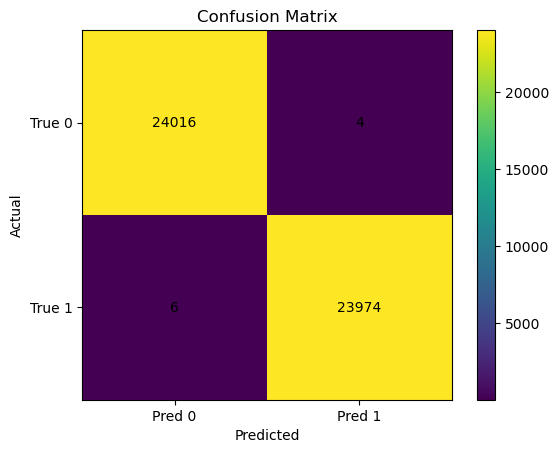

In [38]:
conf_matrix=np.array([[TN,FP],[FN,TP]])
plt.imshow(conf_matrix)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Pred 0", "Pred 1"])
plt.yticks([0,1], ["True 0", "True 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### What is the accuracy?

In [39]:
print("Accuracy:", (TP + TN) / (TP + TN + FP + FN))

Accuracy: 0.9997916666666666


### Now let us see how the model perform on the testing data

#### Write code to do the evaluation on the testing data, what is the testing accuracy? 

In [40]:
TP=TN=FP=FN=0
with tc.no_grad(): # do not compute or store gradient in this block much more efficient
    for xb, yb in test_loader: ### the 1000 batches of test samples
        xb, yb = xb.to(device), yb.to(device)

        preds = model(xb) ### logit score for both classes

        predicted_labels = preds.argmax(dim=1) ## compute max along columns and return index of the maximum value

        TP += ((predicted_labels == 1) & (yb == 1)).sum().item()
        TN += ((predicted_labels == 0) & (yb == 0)).sum().item()
        FP += ((predicted_labels == 1) & (yb == 0)).sum().item()
        FN += ((predicted_labels == 0) & (yb == 1)).sum().item()

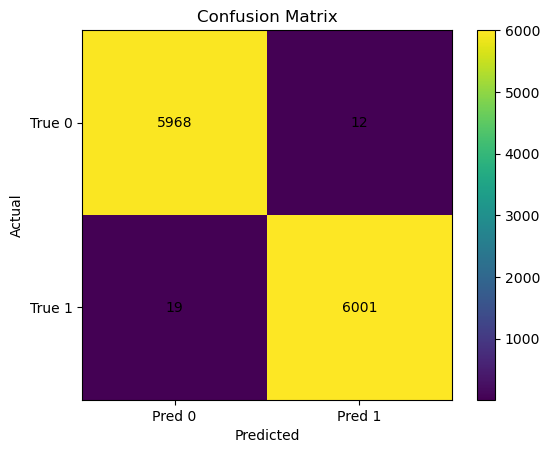

In [41]:
conf_matrix=np.array([[TN,FP],[FN,TP]])
plt.imshow(conf_matrix)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Pred 0", "Pred 1"])
plt.yticks([0,1], ["True 0", "True 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [42]:
print("Accuracy:", (TP + TN) / (TP + TN + FP + FN))

Accuracy: 0.9974166666666666


### Making a temperature list so we can predict the transition temperature

In [43]:
block_size = 10000
num_block = 16
values = [0.25*(i+1) for i in range(num_block)]
temp=[]
for v in values:
    temp.extend([v]*block_size)
temp=np.array(temp)
#######################
temp=temp[60000:120000] # later may want to zoom in around critical temperature
##########################3

### (Guess the function before you run) Randomly select 10% to detect the phase transition temperature.




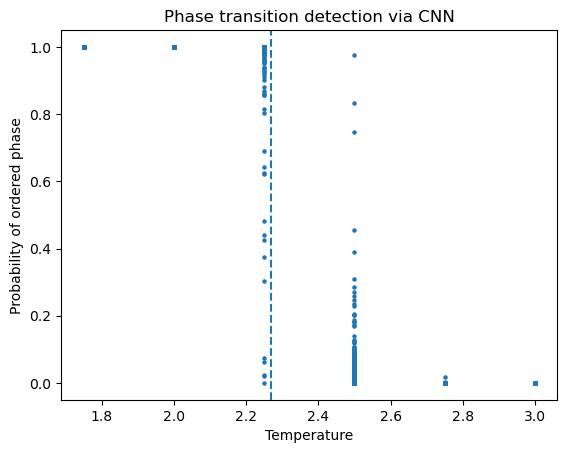

In [46]:
import random
n= 16000
full=list(range(60000))
idx= sorted(random.sample(full,n))

model.eval()
with tc.no_grad():
    logits = model(X[idx].to(device)) #########  the probability is defined as p_i=e^{logit_i}/sum_je^{logit_j}
    ### so logits is like -\beta E in partition function that is why logits bigger it is more preferred, because lower energy is preferred
    probs = F.softmax(logits, dim=1).cpu().numpy()
    ### dim=1 means normalize along column
phase1_prob = probs[:, 1]
    ### take the probability that it is labeled 1

plt.axvline(x = 2.269185, linestyle = "--")

plt.scatter(temp[idx], phase1_prob, s=5)
plt.xlabel("Temperature")
plt.ylabel("Probability of ordered phase")
plt.title("Phase transition detection via CNN")
plt.show()